In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nareshbhat/health-care-data-set-on-heart-attack-possibility",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/var/folders/9b/2fjcrmgn6cn8c66zrqxjrw780000gn/T/ipykernel_89400/3454345164.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.shape

(303, 14)

In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [30]:
m = df.shape[0]
n = df.shape[1]

y = df[['target']]
X = df.drop(columns=['target'])

X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

X_scaled.shape, y.shape

((303, 13), (303, 1))

In [45]:
def loss_function(y, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    error = 0
    for i in range(m):
        error += y[i] * np.log(y_pred[i]) + (1 - y[i]) * np.log(1 - y_pred[i])
    return -error / m

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def calculate_derivative(X, y, y_pred):
    return (1 / m) * np.dot(X.T, y_pred - y)

def predict(X, theta):
    return sigmoid(np.dot(X, theta))

def calc_accuracy(y, y_pred):
    return np.mean(y_pred == y)

def calc_probobility(y, threshhold=0.5):
    return (y >= threshhold).astype(int)

In [46]:
def train(X, y, learning_rate=0.001, epochs=1000, history_interval=100):
    history = {}
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    # Initial weights and bias
    theta = np.zeros(X_b.shape[1])

    for epoch in range(epochs):
        y_pred = predict(X_b, theta)
        theta -= learning_rate * calculate_derivative(X_b, y, y_pred)

        if epoch % history_interval == 0:
            loss = loss_function(y, y_pred)
            print(f"Epoch {epoch}, Loss: {loss}")
            history[epoch] = loss
    
    return theta, history

In [47]:
theta, history = train(X_scaled.values, y.values.flatten(), learning_rate=0.1, epochs=10000, history_interval=100)

Epoch 0, Loss: 0.6931471805599467
Epoch 100, Loss: 0.3601023358195643
Epoch 200, Loss: 0.35138248313700193
Epoch 300, Loss: 0.3496290347792889
Epoch 400, Loss: 0.3491435587858006
Epoch 500, Loss: 0.34898937479001985
Epoch 600, Loss: 0.34893622788872236
Epoch 700, Loss: 0.3489167911472166
Epoch 800, Loss: 0.3489093406682033
Epoch 900, Loss: 0.34890637277891334
Epoch 1000, Loss: 0.34890515290772495
Epoch 1100, Loss: 0.34890463880223116
Epoch 1200, Loss: 0.3489044178524344
Epoch 1300, Loss: 0.3489043214562199
Epoch 1400, Loss: 0.34890427891954656
Epoch 1500, Loss: 0.3489042599886297
Epoch 1600, Loss: 0.3489042515094823
Epoch 1700, Loss: 0.34890424769343464
Epoch 1800, Loss: 0.3489042459697766
Epoch 1900, Loss: 0.3489042451890516
Epoch 2000, Loss: 0.34890424483465204
Epoch 2100, Loss: 0.34890424467349573
Epoch 2200, Loss: 0.34890424460010677
Epoch 2300, Loss: 0.3489042445666458
Epoch 2400, Loss: 0.3489042445513725
Epoch 2500, Loss: 0.34890424454439467
Epoch 2600, Loss: 0.34890424454120345


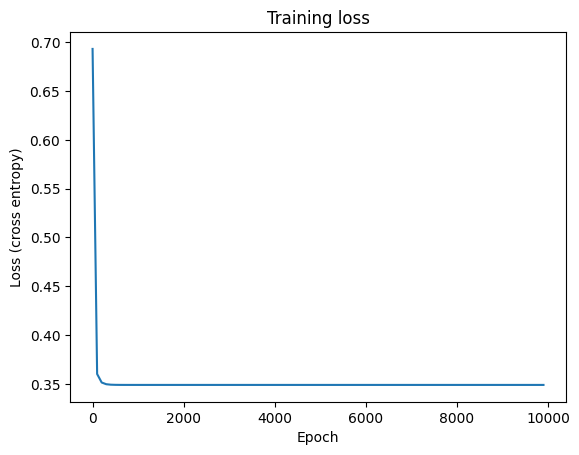

In [48]:
def visualize_loss(history):
    epochs_list = sorted(history.keys())
    loss_list = [history[e] for e in epochs_list]

    plt.plot(epochs_list, loss_list)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (cross entropy)')
    plt.title('Training loss')
    plt.show()
    

visualize_loss(history)

In [51]:
X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled.values]
y_true = y.values.flatten()
y_probs = predict(X_b, theta)
y_pred = calc_probobility(y_probs)

accuracy = calc_accuracy(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f} ({int(accuracy * m)}/{m})")

Accuracy: 0.8515 (258/303)


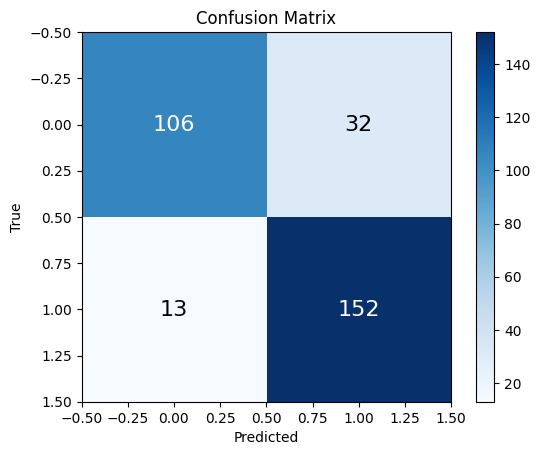

In [52]:
def visualize_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    cm = np.array([[tn, fp], [fn, tp]])

    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=16)

    plt.show()
    
visualize_confusion_matrix(y_true, y_pred)

array([ 0.11647863, -0.04457922, -0.81933125,  0.8874113 , -0.34158375,
       -0.23998837,  0.01242691,  0.24519899,  0.5316502 , -0.4603895 ,
       -0.62729858,  0.3569725 , -0.79083189, -0.55131328])